In [37]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/johnsmith88/heart-disease-dataset/heart.csv


**1. Import Libraries**

In [38]:
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

**2. Load Dataset**

In [39]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        

/kaggle/input/datasets/johnsmith88/heart-disease-dataset/heart.csv


In [40]:
df = pd.read_csv("/kaggle/input/datasets/johnsmith88/heart-disease-dataset/heart.csv")

print(df.head())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  


In [41]:
print(df.columns)

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')


**3. Preprocess Data**

In [42]:
X = df.drop("target", axis=1)

y = df["target"]

**4. Split the Dataset**

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

**5. Normalize the Data**

In [44]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

**6. Convert Data to PyTorch Tensors**

In [45]:
X_train = torch.tensor(X_train, dtype=torch.float32)

X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(
    y_train.values,
    dtype=torch.float32
).view(-1, 1)

y_test = torch.tensor(
    y_test.values,
    dtype=torch.float32
).view(-1, 1)

**7. Build the ANN Model**

In [46]:
model = nn.Sequential(
    nn.Linear(13, 16),
    nn.ReLU(),
    nn.Linear(16, 8),
    nn.ReLU(),
    nn.Linear(8, 1),
    nn.Sigmoid()
)

print(model)

Sequential(
  (0): Linear(in_features=13, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=8, bias=True)
  (3): ReLU()
  (4): Linear(in_features=8, out_features=1, bias=True)
  (5): Sigmoid()
)


**8. Loss Function and Optimizer**

In [47]:
loss_fn = nn.BCELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

**9. Train the Model**

In [48]:
losses = []

for epoch in range(100):

    output = model(X_train)

    loss = loss_fn(output, y_train)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    losses.append(loss.item())

    if (epoch + 1) % 10 == 0:
        print(
            "Epoch:",
            epoch + 1,
            "Loss:",
            loss.item()
        )

Epoch: 10 Loss: 0.6886955499649048
Epoch: 20 Loss: 0.6784511804580688
Epoch: 30 Loss: 0.6676294803619385
Epoch: 40 Loss: 0.6530349254608154
Epoch: 50 Loss: 0.6330294013023376
Epoch: 60 Loss: 0.6070926785469055
Epoch: 70 Loss: 0.5754438638687134
Epoch: 80 Loss: 0.5390416383743286
Epoch: 90 Loss: 0.4995950758457184
Epoch: 100 Loss: 0.4602242112159729


**10. Test the Model**

In [49]:
with torch.no_grad():

    output = model(X_test)

    predicted = (output >= 0.5).float()

**11. Evaluate the Model**

In [50]:
y_true = y_test.numpy()
y_pred = predicted.numpy()

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(y_true, y_pred)

recall = recall_score(y_true, y_pred)

f1 = f1_score(y_true, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.7658536585365854
Precision: 0.7272727272727273
Recall   : 0.8543689320388349
F1 Score : 0.7857142857142857


**12. Confusion Matrix**

In [51]:
cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[69 33]
 [15 88]]


**13. Visualize Training Loss**

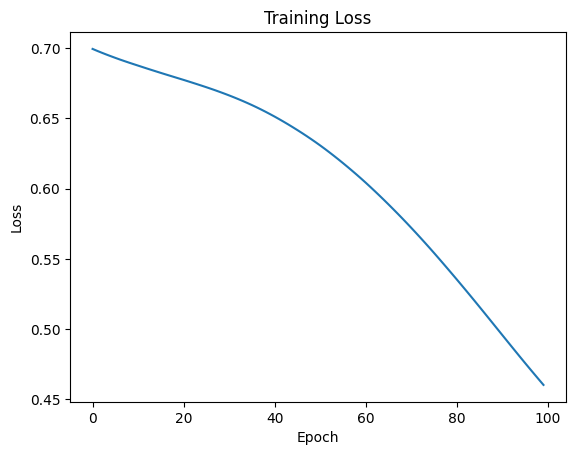

In [52]:
plt.plot(losses)

plt.title("Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.show()

**14. Visualize Confusion Matrix**

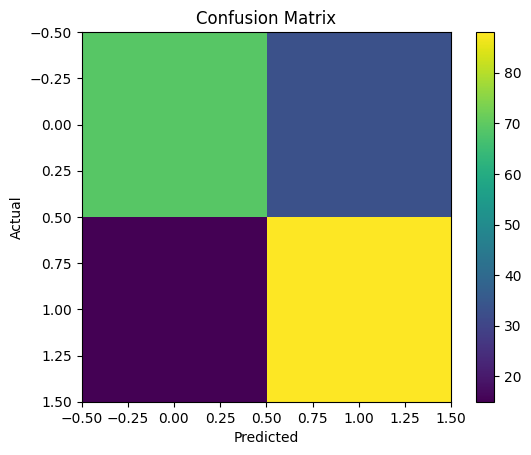

In [53]:
plt.imshow(cm)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.colorbar()

plt.show()

**16. Conclusion**
The Heart Disease dataset was successfully loaded and preprocessed for binary classification. An Artificial Neural Network was built using PyTorch with two hidden layers and a sigmoid output layer. The model was trained using Binary Cross-Entropy loss and the Adam optimizer. Accuracy, precision, recall, F1-score, and the confusion matrix were used to evaluate the model. The training-loss graph shows the learning process, while the confusion matrix shows the correct and incorrect predictions. Overall, the ANN successfully learned patterns in the dataset and performed binary classification of the target variable.